In [1]:
from follow_the_drow.datasets import DROW_Dataset, LiveDataset
from follow_the_drow.detectors import AlgorithmicDetector

from follow_the_drow.utils.file_utils import file_cache_function
from follow_the_drow.utils.drow_utils import linearize, calc_prec_rec_softmax
from follow_the_drow.utils.plot_utils import plot_prec_rec

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# Font which got unicode math stuff.
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# Much more readable plots
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# https://github.com/ipython/ipython/issues/7270#issuecomment-355276432
matplotlib.interactive(False)

In [3]:
te = DROW_Dataset()
print(f"Dataset includes {len(te.scan_id)} scans and {len(te.det_id)} detections")

Scans from test/*.csv loaded!
Detections from test/*.[wc|wa|wp] loaded!
Detections from test/*.odom2 loaded!
Dataset includes 5 scans and 5 detections


In [4]:
dataset = LiveDataset()
detector = AlgorithmicDetector(dataset.time_frame, verbose=False)

def process_test_set():
    seqs, scans, wcs, was, wps = linearize(te.scan_id, te.scans, te.det_id, te.det_wc, te.det_wa, te.det_wp)
    people = detector.forward_all(te)
    return seqs, scans, wcs, was, wps, people

def create_results(_, __, wcs, was, wps, people):
    return calc_prec_rec_softmax(wcs, was, wps, people)

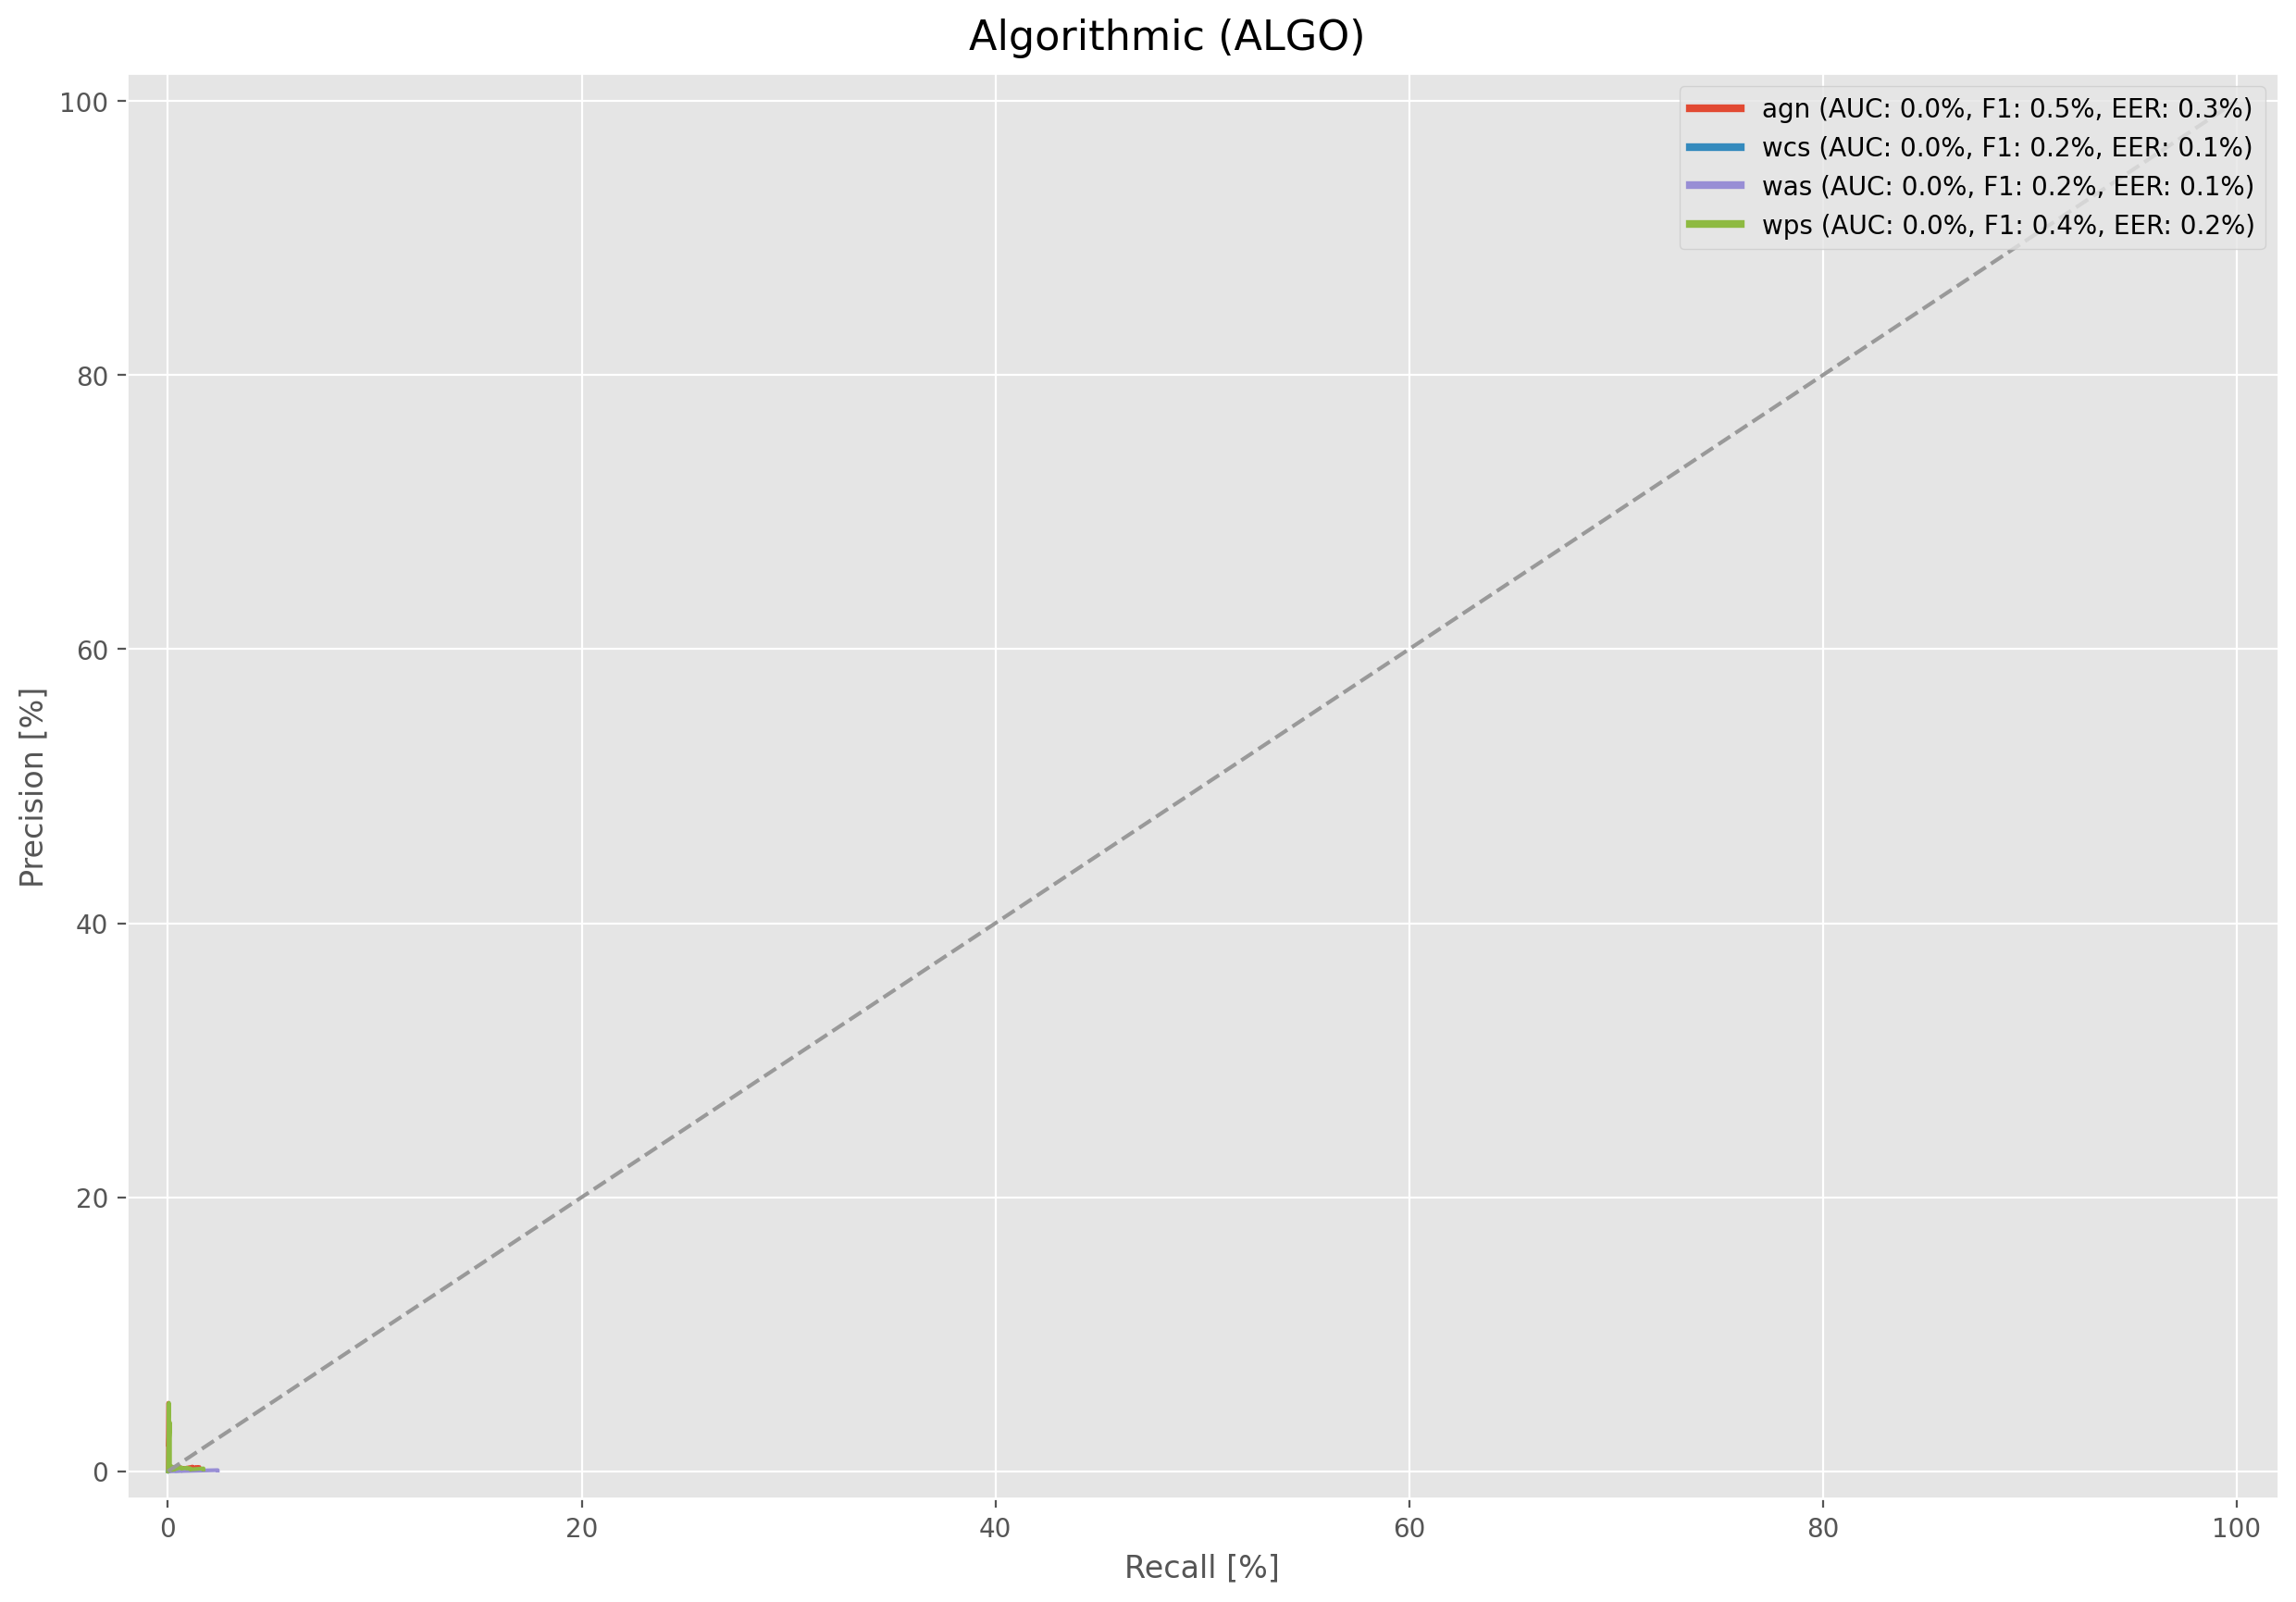

In [5]:
with file_cache_function("algo_data_raw.pkl", process_test_set) as (args, recalc):
    with file_cache_function("algo_data_normal.pkl", create_results, *args, force=recalc) as (results, _):
        fig, _ = plot_prec_rec(*results, title="Algorithmic (ALGO)")
        plt.close(fig)

fig